# Занятие 21. Мини-тест: ML workflow и kNN

Короткая проверка теории. Типы заданий: сопоставление, выбор ответа, открытый ответ, вычисление / код, по картинке.

В ячейках с кодом заполните пропуски (`...`), чтобы прошли `assert`.


## 1. Тип задачи по постановке

**Тип:** сопоставление

**Задание.** Сопоставьте описание с типом задачи.

A. Предсказать, уйдёт ли клиент из сервиса.  
B. Разделить пользователей на группы без готовых меток.  
C. Предсказать цену квартиры.

1. регрессия  
2. классификация  
3. кластеризация

**Правильный ответ:** A-2, B-3, C-1.


## 2. Роли частей данных

**Тип:** сопоставление

**Задание.** Сопоставьте часть данных с ролью.

A. Train  
B. Validation  
C. Test

1. финальная независимая проверка  
2. обучение параметров модели  
3. сравнение идей и подбор гиперпараметров (например, `k`)

**Правильный ответ:** A-2, B-3, C-1.


## 3. Утечка данных

**Тип:** выбор ответа

**Задание.** Прогноз просрочки кредита **на момент заявки**. Какой признак — утечка?

**Варианты ответа:**

A. Возраст клиента на момент заявки.  
B. Доход, указанный в анкете при подаче.  
C. Сумма штрафов через месяц после выдачи кредита.  
D. Город проживания на момент заявки.

**Правильный ответ:** C.


## 4. Baseline при дисбалансе

**Тип:** открытый ответ

**Задание.** Мошенничество встречается в 2% случаев. Модель всегда отвечает «не мошенничество» и имеет accuracy 98%. Почему этого мало, чтобы назвать модель полезной?

**Формат ответа:** 1–3 предложения.

**Правильный ответ:** accuracy высокая из-за дисбаланса, но положительный класс не находится; нужны recall/precision/F1 по редкому классу.


## 5. Масштабирование для kNN

**Тип:** выбор ответа

**Задание.** Есть `возраст` (~10–90) и `доход` (~30 000–300 000). Почему перед kNN масштабируют признаки?

**Варианты ответа:**

A. Чтобы расстояние считалось по числу признаков, а не по значениям.  
B. Чтобы validation можно было использовать как финальный test.  
C. Чтобы категориальные признаки сами стали числовыми.  
D. Чтобы признаки с большими единицами не доминировали в расстоянии.

**Правильный ответ:** D.


## 6. Где учить StandardScaler

**Тип:** выбор ответа

**Задание.** Как обучать `StandardScaler` без утечки?

**Варианты ответа:**

A. `fit` на train+validation+test вместе.  
B. `fit` на train, затем применять к validation и test.  
C. Отдельный `fit` на каждом из train, validation и test.  
D. `fit` только на test, потому что он финальный.

**Правильный ответ:** B.


## 7. Выбор k по картинке

**Тип:** по картинке

**Задание.** На рисунке новый объект (крестик) и train-точки классов A и B. Пунктир — область ближайших соседей при небольшом `k`.

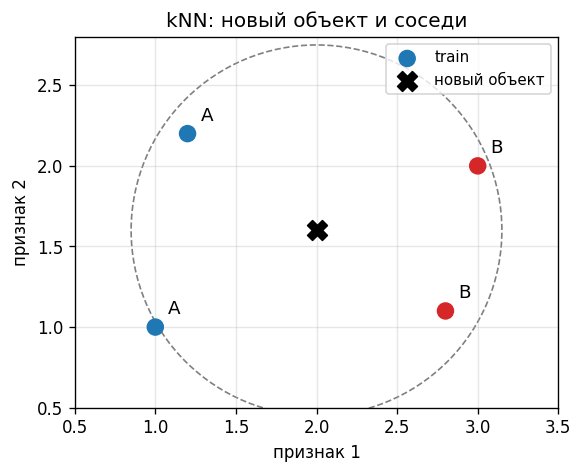

Если взять **k=3** (простое большинство голосов), какой класс получит новый объект и почему это может быть неустойчиво при `k=1`?

**Варианты ответа:**

A. Класс A: среди трёх ближайших два голоса A; при `k=1` ответ зависит от одного соседа и легче переобучается.  
B. Класс B: дальние точки важнее ближних, поэтому побеждает B.  
C. Класс A, и при `k=1` ответ всегда совпадает с ответом при любом `k`.  
D. Класс нельзя определить: kNN не умеет работать с двумя признаками.

**Правильный ответ:** A.


## 8. Голосование соседей

**Тип:** вычисление / код

**Задание.** Соседи уже отсортированы по расстоянию, `k=3`, метки `["A","B","A"]`. Найдите предсказанный класс и число голосов победителя.

**Правильный ответ:** класс `A`, 2 голоса (проверяется assert).


In [ ]:
from collections import Counter

neighbor_labels = ["A", "B", "A"]
votes = Counter(neighbor_labels)

predicted_class = ...  # "A" или "B"
votes_for_winner = ...  # int

assert predicted_class == "A"
assert votes_for_winner == 2
print("ok:", predicted_class, votes_for_winner)


## 9. Доминирование масштаба

**Тип:** по картинке

**Задание.** Слева — точки в «сырых» координатах возраст/доход, справа — после min-max в [0, 1].

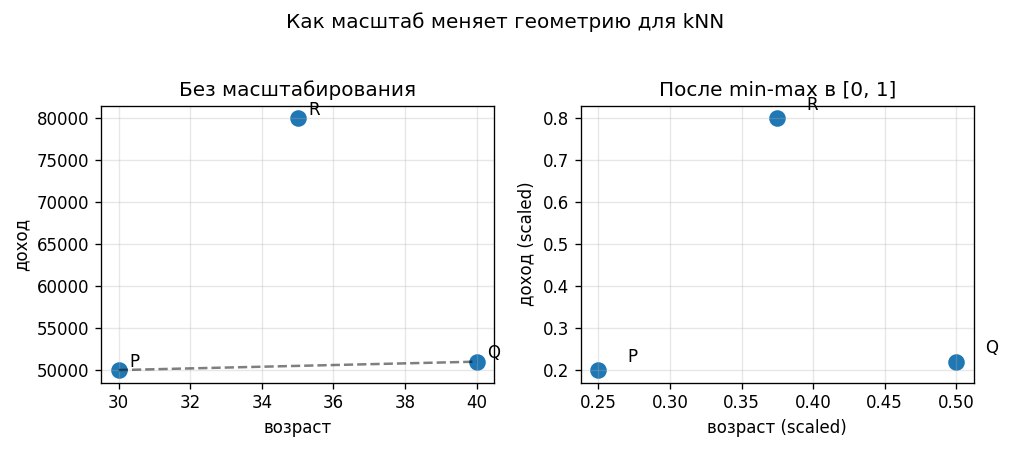

Почему на левом графике расстояние почти целиком определяется доходом, а на правом возраст и доход сравнимы? Ответьте в 1–2 предложениях.

**Правильный ответ:** без масштабирования разница дохода в тысячах «перебивает» разницу возраста в единицах; после масштабирования оба признака в одном диапазоне и вклад в расстояние сопоставим.


## 10. Recall в медицинской задаче

**Тип:** открытый ответ

**Задание.** Модель ищет больных. Что означает высокий recall положительного класса?

**Формат ответа:** 1–3 предложения.

**Правильный ответ:** находит большую долю действительно больных, мало пропускает положительные случаи.
